In [5]:
import numpy as np
import matplotlib.pyplot as plt

# Motion Profile Recognition Through Numerical Analysis

## Motivation

The goal is to describe a practical, implementation-ready approach to classify motions from discrete samples $(t_i, x_i)$ into three candidate types. Data in the beginning is perfect, and then the same methods are applied for data with noise.

### Why this project?

Real-time classification of motion patterns is used in robotics, animation & gaming, wearable sensons, education & research, autonomous vehicles and so on.


## Theoretical background

### Input Data


- Time array: `t = np.linspace(0, 10, 50)`, where we get 50 evently spaced values for time points between 0 and 10
- Position values: $x(t)$ generated from kinematic models
The purpose is by given $(t, x)$ to define what type of motion is that. Each model describs different type of motion. Later we will add noise to simulate real-world measurments.

### Mathematical description of motion types

Kinematic equations describe the relationship between position ($x$), velocity ($v$), acceleration ($a$), and time ($t$). This means that each motion has a unique mathematical fingerprint. We can recognize it by finding out which motion matches the fingerprint, best by applying our data.

#### 1. Linear Motion — constant velocity

**Definition:**
$$ x(t) = x_0 + v \cdot t $$

**Velocity:**
$$ v = \text{constant} $$

**Acceleration:**
$$ a = 0 $$

**Pattern for determination:** Position changes linearly with time. Calculated acceleration is close to zero.

**Mathematical model:**
1. If position $x$ is linear with time $t$:
   $$ x(t) = x_0 + v \cdot t $$
2. Velocity is the first derivative of position:
   $$ v = \frac{dx}{dt} = v $$
3. Acceleration is the derivative of velocity:
   $$ a = \frac{dv}{dt} = 0 $$

**Conclusion:** Constant $v$ and $a = 0$ → uniform motion.

#### 2. Accelerated Motion — constant acceleration

**Definition:**
$$ x(t) = x_0 + v_0 \cdot t + \frac{1}{2} a \cdot t^2 $$

**Velocity:**
$$ v(t) = \frac{dx}{dt} = v_0 + a \cdot t $$

**Acceleration:**
$$ a = \frac{dv}{dt} = \text{constant} $$

**Pattern for determination:** Position changes quadratically with time. Velocity changes linearly, while calculated acceleration stays approximately constant.

**Mathematical model:**
1. If position $x$ is a quadratic function of time $t$:
   $$ x(t) = x_0 + v_0 \cdot t + \frac{1}{2} a \cdot t^2 $$
2. Velocity is the first derivative:
   $$ v = \frac{dx}{dt} = v_0 + a \cdot t $$
3. Acceleration is the derivative of velocity:
   $$ a = \frac{dv}{dt} = \text{constant} $$

**Conclusion:** Constant $a \neq 0$ → accelerated motion.


#### 3. Harmonic Motion — sinusoidal oscillation

**Definition (two equivalent forms):**
$$ x(t) = A \cdot \cos(\omega t + \phi) $$ or $$ x(t) = A \cdot \sin(\omega t + \phi) $$

**Velocity:**
$$ v(t) = \frac{dx}{dt} = -A \omega \cdot \sin(\omega t + \phi) $$

**Acceleration:**
$$ a(t) = \frac{d^2x}{dt^2} = -A \omega^2 \cdot \cos(\omega t + \phi) $$

**Key relationship:**
Since $x(t) = A \cdot \cos(\omega t + \phi)$, then:
$$ a(t) = -\omega^2 \cdot x(t) $$

**Pattern for determination:**
- Position changes periodically with time
- Object moves back and forth around an equilibrium point
- Acceleration is proportional to position, but in the opposite direction ($a \propto -x$)

**Mathematical model:**
1. If position $x$ is a sine or cosine function of time $t$ → motion is harmonic
2. Velocity is the first derivative:
   $$ v = \frac{dx}{dt} $$
3. Acceleration is the second derivative:
   $$ a = \frac{d^2x}{dt^2} $$
4. For harmonic motion, the defining relationship is:
   $$ a = -\omega^2 \cdot x $$

**Conclusion:** Acceleration always points toward the center of motion → harmonic oscillation.

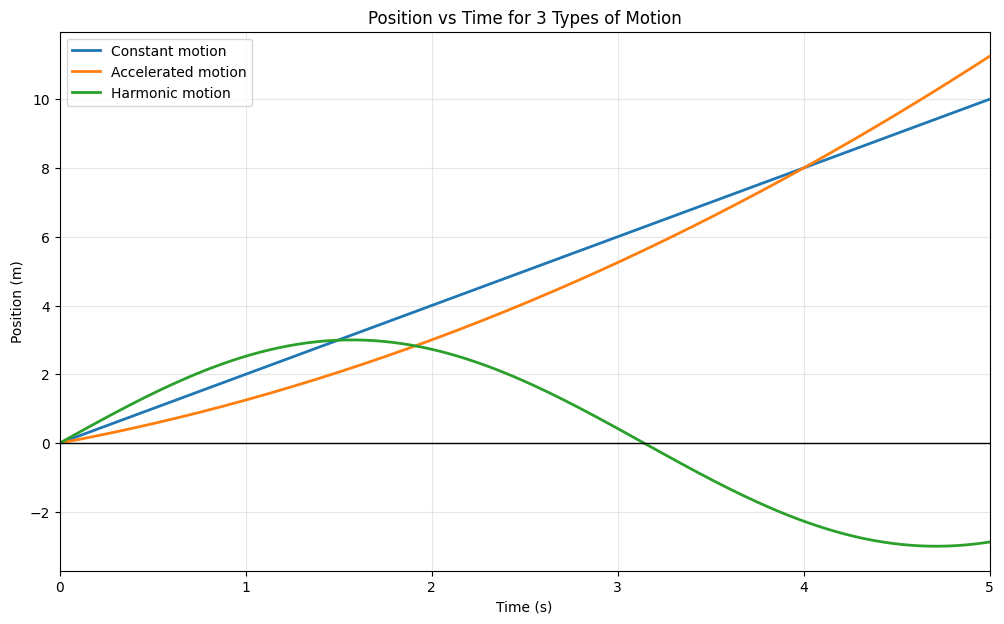

In [31]:
# Define the physical models

def constant_motion(t, x0, v):
    return x0 + v * t

def accelerated(t, x0, v0, a):
    return x0 + v0 * t + 0.5 * a * t**2

def harmonic(t, A, omega, phi):
    return A * np.sin(omega * t + phi)

# generating af data
t = np.linspace(0, 5, 200)

x_uniform = constant_motion(t, x0=0, v=2.0)
x_accel = accelerated(t, x0=0, v0=1.0, a=0.5)
x_harmonic = harmonic(t, A=3.0, omega=1.0, phi=0)

plt.figure(figsize=(12, 7))
plt.plot(t, x_uniform, label='Constant motion', linewidth=2)
plt.plot(t, x_accel, label='Accelerated motion', linewidth=2)
plt.plot(t, x_harmonic, label='Harmonic motion', linewidth=2)

plt.axhline(0, color='black', linewidth=1)
plt.xlabel('Time (s)')
plt.ylabel('Position (m)')
plt.title('Position vs Time for 3 Types of Motion')
plt.legend()
plt.grid(True, alpha=0.3)
plt.xlim(0, 5)
plt.margins(x=0)

plt.show()

> **Figure 1:** The blue line represents constant motion. Its graph is a straight line because the position changes by the same amount in equal time intervals. This means the velocity is constant and the acceleration is zero.
>The orange line represents accelerated motion. Its graph is curved upward because the position increases faster over time. This means the velocity is changing, and the acceleration is constant and positive.
>The green line represents harmonic motion. Its graph has a wave-like shape because the object moves periodically back and forth around an equilibrium position. This type of motion is described by a sine or cosine function.
>All three motions are shown on the same coordinate system, where the horizontal axis represents time and the vertical axis represents position.

## Methodology

To make the experiment more realistic, noise is added to the ideal trajectories. In real measurements, data is usually not perfect because of sensor limitations, environmental effects, or signal processing errors.

We model this by adding random Gaussian noise to the true position values:

$$
x_{\text{observed}} = x_{\text{true}} + \epsilon
$$

where $\epsilon$ is a random error term.

We assume:

$$
\epsilon \sim \mathcal{N}(0, \sigma^2)
$$

This means that most errors are small and centered around zero, while larger errors happen less often.

The parameter $\sigma$ determines the noise level:
- small $\sigma$ means cleaner data
- large $\sigma$ means noisier data

This allows us to test whether the motion type can still be recognized when the observations are imperfect.

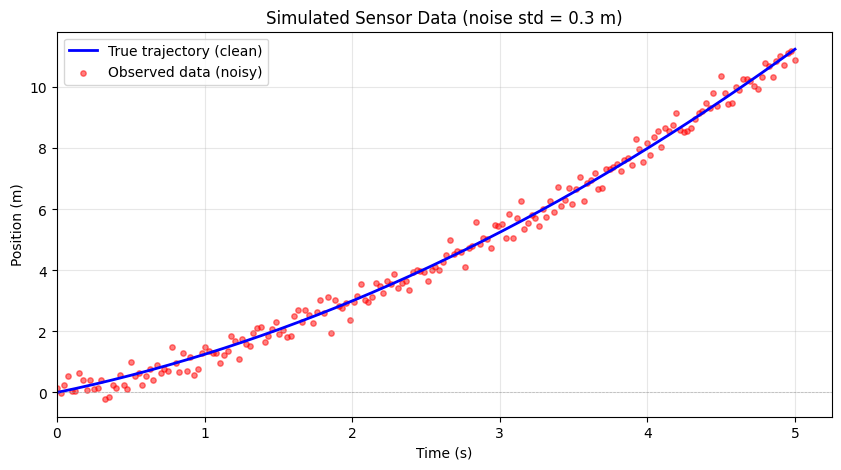

In [34]:
# === Add realistic noise to ONE trajectory (e.g., accelerated) ===
np.random.seed(42)  # For reproducible results

# Parameters for noise
noise_std = 0.3  # Standard deviation in meters (adjust to test robustness)

# Generate Gaussian noise: mean=0, std=noise_std, same length as time array
noise = np.random.normal(loc=0, scale=noise_std, size=len(t))

# Add noise to the accelerated trajectory (our "observed" data)
x_observed = x_accel + noise

# === Visualize: Clean vs. Noisy ===
plt.figure(figsize=(10, 5))
plt.plot(t, x_accel, 'b-', linewidth=2, label='True trajectory (clean)')
plt.scatter(t, x_observed, c='red', s=15, alpha=0.5, label='Observed data (noisy)')
plt.axhline(y=0, color='gray', linestyle='--', linewidth=0.5, alpha=0.5)
plt.xlabel('Time (s)')
plt.ylabel('Position (m)')
plt.title(f'Simulated Sensor Data (noise std = {noise_std} m)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.xlim(left=0)
plt.xticks(np.arange(0, 6, 1))
plt.show()

> **Figure 2:** Simulated sensor measurements for accelerated motion. 
> Red points: noisy observations ($\sigma = 0.3$ m). Blue line: ground-truth trajectory. 
> The recognition algorithm must recover the underlying model from the noisy points.

## Methodology (f.ex. Least Squares/Optimisation)
## 2D Simulation

## Movement recognition(Curve Fit)

## 3D Simulation

## Conclusion

## References

